In [1]:
from cobra.io import read_sbml_model
from cobra.flux_analysis import pfba
from cobra import Reaction
import pandas as pd

# =========================
# 1. 加载模型
# =========================
def load_rhizopus_model():
    model = read_sbml_model("./data/Rhizopus_M9.xml")

    # 修正部分 exchange 方向
    for rid in [
        "EX_cl_e", "EX_cobalt2_e", "EX_cu2_e",
        "EX_glc__D_e", "EX_14glucan_e", "EX_glucan4_e", "EX_glucan6_e",
        "EX_o2_e", "EX_nh4_e", "EX_pi_e", "EX_so4_e"
    ]:
        if rid in model.reactions:
            rxn = model.reactions.get_by_id(rid)
            rxn.lower_bound = -1000
            rxn.upper_bound = 1000

    return model


# =========================
# 2. 添加胞外 glucan/starch 水解反应
# =========================
def add_extracellular_glucan_hydrolysis(model, coeff=10):
    substrates = ["14glucan_e", "glucan4_e", "glucan6_e"]
    glucose_id = "glc__D_e"

    if glucose_id not in [m.id for m in model.metabolites]:
        raise ValueError(f"{glucose_id} not found in metabolites")

    glucose = model.metabolites.get_by_id(glucose_id)

    for sid in substrates:
        if sid not in [m.id for m in model.metabolites]:
            continue

        rxn_id = f"HYDROLYSIS_{sid}"
        if rxn_id in [r.id for r in model.reactions]:
            continue

        substrate = model.metabolites.get_by_id(sid)

        rxn = Reaction(rxn_id)
        rxn.name = f"Extracellular hydrolysis of {sid}"
        rxn.lower_bound = 0.0
        rxn.upper_bound = 1000.0

        # 简化表示：1 glucan -> 10 glucose
        rxn.add_metabolites({
            substrate: -1.0,
            glucose: float(coeff)
        })

        model.add_reactions([rxn])
        print("Added:", rxn.id, "|", rxn.reaction)

    return model


# =========================
# 3. 运行单个条件
# =========================
def run_condition(base_model, condition_name, carbon_source_id, carbon_uptake, oxygen_uptake):
    model = base_model.copy()

    # 每次从所有 exchanges 重建完整培养基
    medium = {rxn.id: 0.0 for rxn in model.exchanges}

    # 基础无机培养基
    base_allowed = {
        "EX_o2_e": oxygen_uptake,
        "EX_nh4_e": 10.0,
        "EX_pi_e": 10.0,
        "EX_so4_e": 10.0,
        "EX_h2o_e": 1000.0,
        "EX_h_e": 1000.0,
        "EX_k_e": 1000.0,
        "EX_na1_e": 1000.0,
        "EX_mg2_e": 1000.0,
        "EX_ca2_e": 1000.0,
        "EX_fe2_e": 1000.0,
        "EX_fe3_e": 1000.0,
        "EX_mn2_e": 1000.0,
        "EX_zn2_e": 1000.0,
        "EX_cl_e": 1000.0,
        "EX_cobalt2_e": 1000.0,
        "EX_cu2_e": 1000.0,
    }

    for rid, val in base_allowed.items():
        if rid in medium:
            medium[rid] = val

    # 打开当前碳源
    if carbon_source_id not in medium:
        print(f"[Skip] {condition_name}: {carbon_source_id} not in model.exchanges")
        return None

    medium[carbon_source_id] = carbon_uptake
    model.medium = medium

    # FBA 取生长率
    sol_fba = model.optimize()

    # pFBA 取 flux
    sol_pfba = pfba(model)

    print("=" * 60)
    print(condition_name)
    print("=" * 60)
    print("Status:", sol_fba.status)
    print("Growth rate:", sol_fba.objective_value)
    print()

    print("=== Uptake ===")
    for rxn in model.exchanges:
        flux = sol_pfba.fluxes[rxn.id]
        if flux < -1e-6:
            print(rxn.id, flux)

    print("\n=== Secretion ===")
    for rxn in model.exchanges:
        flux = sol_pfba.fluxes[rxn.id]
        if flux > 1e-6:
            print(rxn.id, flux)

    print()

    return {
        "condition": condition_name,
        "model": model,
        "fba_solution": sol_fba,
        "pfba_solution": sol_pfba
    }


# =========================
# 4. 分类函数
# =========================
def classify_metabolite(rxn_id, rxn_name):
    text = f"{rxn_id} {rxn_name}".lower()

    if any(k in text for k in ["glc", "glucan", "starch", "malt"]):
        return "carbon"
    elif any(k in text for k in ["nh4", "ammon"]):
        return "nitrogen"
    elif any(k in text for k in ["o2", "co2"]):
        return "gas"
    elif any(k in text for k in ["acet", "lac", "form", "etoh", "acald", "h2s"]):
        return "fermentation_product"
    elif any(k in text for k in ["pi", "so4", "fe", "mg", "ca", "na", "k", "mn", "zn", "cl", "cu", "cobalt", "h2o", "h+"]):
        return "ion_or_inorganic"
    else:
        return "other"


# =========================
# 5. 主流程
# =========================
model = load_rhizopus_model()
model = add_extracellular_glucan_hydrolysis(model, coeff=10)

conditions = [
    ("glucose_aerobic", "EX_glc__D_e", 10, 20),
    ("glucose_low_o2", "EX_glc__D_e", 10, 5),
    ("dextrin_aerobic", "EX_14glucan_e", 10, 20),
    ("starch_aerobic", "EX_glucan4_e", 10, 20),
]

results = []

for name, cid, cup, o2 in conditions:
    res = run_condition(model, name, cid, cup, o2)
    if res is not None:
        results.append(res)


# =========================
# 6. 导出 exchange flux summary
# =========================
rows = []

for res in results:
    cond = res["condition"]
    m = res["model"]
    sol = res["pfba_solution"]

    for rxn in m.exchanges:
        flux = sol.fluxes[rxn.id]
        if abs(flux) > 1e-6:
            rows.append({
                "species": "R_microsporus",
                "condition": cond,
                "rxn_id": rxn.id,
                "rxn_name": rxn.name,
                "flux": float(flux),
                "direction": "uptake" if flux < 0 else "secretion",
                "metabolite_class": classify_metabolite(rxn.id, rxn.name)
            })

df_flux = pd.DataFrame(rows)
df_flux.to_csv("./data/R_microsporus_exchange_flux_summary.csv", index=False)

print("Saved: ./data/R_microsporus_exchange_flux_summary.csv")


# =========================
# 7. 导出生长率 summary
# =========================
growth_rows = []

for res in results:
    growth_rows.append({
        "species": "R_microsporus",
        "condition": res["condition"],
        "status": res["fba_solution"].status,
        "growth_rate": float(res["fba_solution"].objective_value)
    })

df_growth = pd.DataFrame(growth_rows)
df_growth.to_csv("./data/R_microsporus_growth_summary.csv", index=False)

print("Saved: ./data/R_microsporus_growth_summary.csv")
print(df_growth)

Adding exchange reaction EX_12ppd__S_e with default bounds for boundary metabolite: 12ppd__S_e.
Adding exchange reaction EX_14glucan_e with default bounds for boundary metabolite: 14glucan_e.
Adding exchange reaction EX_25dkglcn_e with default bounds for boundary metabolite: 25dkglcn_e.
Adding exchange reaction EX_2dhglcn_e with default bounds for boundary metabolite: 2dhglcn_e.
Adding exchange reaction EX_2m35mdntha_e with default bounds for boundary metabolite: 2m35mdntha_e.
Adding exchange reaction EX_2mbald_e with default bounds for boundary metabolite: 2mbald_e.
Adding exchange reaction EX_2obut_e with default bounds for boundary metabolite: 2obut_e.
Adding exchange reaction EX_2pglyc_e with default bounds for boundary metabolite: 2pglyc_e.
Adding exchange reaction EX_34dhbz_e with default bounds for boundary metabolite: 34dhbz_e.
Adding exchange reaction EX_34dhpac_e with default bounds for boundary metabolite: 34dhpac_e.
Adding exchange reaction EX_35dnta_e with default bounds f

Added: HYDROLYSIS_14glucan_e | 14glucan_e --> 10.0 glc__D_e
Added: HYDROLYSIS_glucan4_e | glucan4_e --> 10.0 glc__D_e
Added: HYDROLYSIS_glucan6_e | glucan6_e --> 10.0 glc__D_e
glucose_aerobic
Status: optimal
Growth rate: 0.3836494825668141

=== Uptake ===
EX_ca2_e -0.0019968955567602675
EX_cl_e -0.0019968955567602675
EX_cobalt2_e -3.836494825668141e-05
EX_cu2_e -0.0002720074831398712
EX_fe2_e -0.005676190006946651
EX_glc__D_e -10.0
EX_h_e -10.37857917100528
EX_k_e -0.07488569345066415
EX_mg2_e -0.0033281592612671124
EX_mn2_e -0.0002651017924536685
EX_nh4_e -4.296226604421869
EX_o2_e -20.00000000000071
EX_pi_e -0.37831406921282484
EX_so4_e -0.0961525352177904
EX_zn2_e -0.0001308244735552836

=== Secretion ===
EX_acald_e 10.572632957483009
EX_co2_e 22.482094763806256
EX_h2o_e 40.36054619412955
EX_pheme_e 0.0001044485716288103

glucose_low_o2
Status: optimal
Growth rate: 0.22408519870238233

=== Uptake ===
EX_ca2_e -0.0011663634592459001
EX_cl_e -0.0011663634592459001
EX_cobalt2_e -2.2408

In [2]:
print(model.reactions.get_by_id("HYDROLYSIS_glucan4_e").reaction)
print(model.reactions.get_by_id("HYDROLYSIS_14glucan_e").reaction)

glucan4_e --> 10.0 glc__D_e
14glucan_e --> 10.0 glc__D_e


In [3]:
df_growth

,species,condition,status,growth_rate
0,R_microsporus,glucose_aerobic,optimal,0.383649
1,R_microsporus,glucose_low_o2,optimal,0.224085
2,R_microsporus,dextrin_aerobic,optimal,0.892992
3,R_microsporus,starch_aerobic,optimal,0.892992


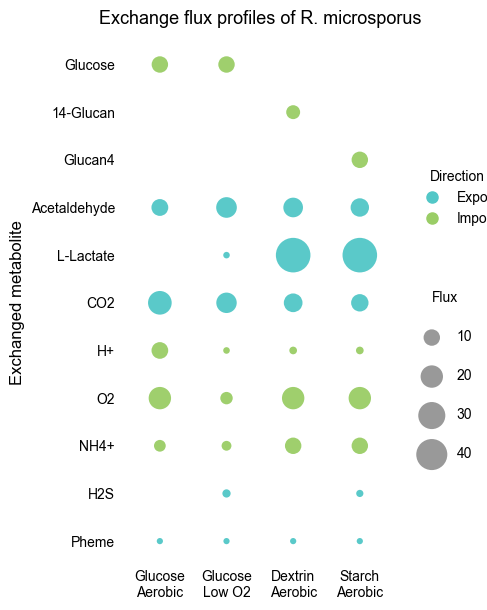

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

# ==============================
# 0. PDF 字体可编辑
# ==============================
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

# ==============================
# 1. 读取数据
# ==============================
df = pd.read_csv("./data/R_microsporus_exchange_flux_summary.csv")

# ==============================
# 2. 过滤：保留所有非0 exchange，但去掉不想展示的无机离子/水
# ==============================
exclude_patterns = [
    "EX_fe3_e",
    "EX_fe2_e",
    "EX_ca2_e",
    "EX_so4_e",
    "EX_k_e",
    "EX_mg2_e",
    "EX_pi_e",
    "EX_h2o_e",
    "EX_na1_e",
    "EX_cl_e",
    "EX_cobalt2_e",
    "EX_cu2_e",
    "EX_mn2_e",
    "EX_zn2_e"
]

df_plot = df[~df["rxn_id"].isin(exclude_patterns)].copy()

# ==============================
# 3. 美化名称
# ==============================
rxn_name_map = {
    "EX_glc__D_e": "Glucose",
    "EX_malt_e": "Maltose",
    "EX_dextrin_e": "Dextrin",
    "EX_starch_e": "Starch",
    "EX_14glucan_e": "14-Glucan",
    "EX_glucan4_e": "Glucan4",
    "EX_glucan6_e": "Glucan6",
    "EX_ac_e": "Acetate",
    "EX_acald_e": "Acetaldehyde",
    "EX_lac__L_e": "L-Lactate",
    "EX_for_e": "Formate",
    "EX_co2_e": "CO2",
    "EX_h_e": "H+",
    "EX_o2_e": "O2",
    "EX_nh4_e": "NH4+",
    "EX_glyclt_e": "Glycolate",
    "EX_h2s_e": "H2S",
    "EX_pheme_e": "Pheme"
}

df_plot["Metabolite"] = df_plot["rxn_id"].map(rxn_name_map).fillna(df_plot["rxn_id"])

# ==============================
# 4. 条件顺序
# ==============================
condition_order = [
    "glucose_aerobic",
    "glucose_low_o2",
    "maltose_aerobic",
    "dextrin_aerobic",
    "starch_aerobic"
]

condition_name_map = {
    "glucose_aerobic": "Glucose\nAerobic",
    "glucose_low_o2": "Glucose\nLow O2",
    "maltose_aerobic": "Maltose\nAerobic",
    "dextrin_aerobic": "Dextrin\nAerobic",
    "starch_aerobic": "Starch\nAerobic"
}

df_plot["Condition"] = df_plot["condition"].map(condition_name_map)

# ==============================
# 5. 代谢物顺序：严格按 rxn_name_map 顺序，只保留当前数据存在的
# ==============================
metabolite_order = [
    m for m in rxn_name_map.values()
    if m in df_plot["Metabolite"].unique()
]

df_plot["Metabolite"] = pd.Categorical(
    df_plot["Metabolite"],
    categories=metabolite_order,
    ordered=True
)

# ==============================
# 6. 方向和气泡大小
# ==============================
df_plot["Direction"] = df_plot["flux"].apply(lambda x: "Import" if x < 0 else "Export")

df_plot["AbsFlux"] = df_plot["flux"].abs().clip(upper=50)

size_scale = 12
min_size = 20
df_plot["s"] = df_plot["AbsFlux"] * size_scale + min_size

# ==============================
# 7. 坐标映射
# ==============================
x_labels = [condition_name_map[c] for c in condition_order if c in df_plot["condition"].unique()]
x_map = {name: i for i, name in enumerate(x_labels)}
y_map = {name: i for i, name in enumerate(metabolite_order)}

df_plot["x"] = df_plot["Condition"].map(x_map)
df_plot["y"] = df_plot["Metabolite"].map(y_map)

df_plot = df_plot.dropna(subset=["x", "y"]).copy()

# ==============================
# 8. 配色
# ==============================
palette = {
    "Export": "#52C7C7",
    "Import": "#9ACD66"
}

# ==============================
# 9. 作图
# ==============================
fig, ax = plt.subplots(figsize=(5, 6.2))

for direction in ["Export", "Import"]:
    sub = df_plot[df_plot["Direction"] == direction]
    ax.scatter(
        sub["x"],
        sub["y"],
        s=sub["s"],
        c=palette[direction],
        alpha=0.95,
        edgecolors="none",
        linewidths=0,
        label=direction
    )

# ==============================
# 10. 坐标轴设置
# ==============================
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=10)

ax.set_yticks(range(len(metabolite_order)))
ax.set_yticklabels(metabolite_order, fontsize=10)

ax.tick_params(axis='both', length=0)
ax.set_xlim(-0.6, len(x_labels) - 0.4)

ax.invert_yaxis()
ax.set_xlabel("")
ax.set_ylabel("Exchanged metabolite", fontsize=12)
ax.set_title("Exchange flux profiles of R. microsporus", fontsize=13, pad=12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)
ax.set_facecolor("none")
fig.patch.set_alpha(0)

# ==============================
# 11. 图例
# ==============================
export_patch = mlines.Line2D([], [], color=palette["Export"], marker="o", linestyle="None",
                             markersize=8, label="Export")
import_patch = mlines.Line2D([], [], color=palette["Import"], marker="o", linestyle="None",
                             markersize=8, label="Import")

legend1 = ax.legend(
    handles=[export_patch, import_patch],
    title="Direction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.70),
    frameon=False
)
ax.add_artist(legend1)

legend_flux = [10, 20, 30, 40]
size_handles = [
    ax.scatter([], [], s=flux * size_scale + min_size, color="gray", alpha=0.8,
               edgecolors="none", linewidths=0)
    for flux in legend_flux
]

legend2 = ax.legend(
    handles=size_handles,
    labels=[str(x) for x in legend_flux],
    title="Flux",
    loc="center left",
    bbox_to_anchor=(1.02, 0.36),
    frameon=False,
    labelspacing=1.8
)

# ==============================
# 12. 输出
# ==============================
plt.tight_layout()
plt.savefig(
    "R_microsporus_exchange_bubbleplot.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

In [4]:
import pandas as pd

met_rows = []

for met in model.metabolites:
    met_rows.append({
        "metabolite_id": met.id,
        "metabolite_name": met.name,
        "compartment": met.compartment,
        "formula": getattr(met, "formula", None),
        "charge": getattr(met, "charge", None)
    })

met_df = pd.DataFrame(met_rows)

met_df.to_csv("./data/R_microsporus_metabolites.csv", index=False)

print("Saved: R_microsporus_metabolites.csv")
met_df.head()

Saved: R_microsporus_metabolites.csv


,metabolite_id,metabolite_name,compartment,formula,charge
0,10fthf_c,10-Formyltetrahydrofolate,C_c,C20H21N7O7,-2
1,12dgr120_c,"1,2-Diacyl-sn-glycerol (didodecanoyl, n-C12:0)",C_c,C27H52O5,0
2,12dgr120_p,"1,2-Diacyl-sn-glycerol (didodecanoyl, n-C12:0)",C_p,C27H52O5,0
3,12dgr140_c,"1,2-Diacyl-sn-glycerol (ditetradecanoyl, n-C14:0)",C_c,C31H60O5,0
4,12dgr140_p,"1,2-Diacyl-sn-glycerol (ditetradecanoyl, n-C14:0)",C_p,C31H60O5,0


In [5]:
rxn_rows = []

for rxn in model.reactions:

    # subsystem（有些模型在 annotation）
    subsystem = None
    if hasattr(rxn, "subsystem"):
        subsystem = rxn.subsystem

    if not subsystem and hasattr(rxn, "annotation"):
        subsystem = rxn.annotation.get("subsystem", None)

    rxn_rows.append({
        "reaction_id": rxn.id,
        "reaction_name": rxn.name,
        "equation": rxn.reaction,
        "lower_bound": rxn.lower_bound,
        "upper_bound": rxn.upper_bound,
        "gene_rule": rxn.gene_reaction_rule,
        "subsystem": subsystem
    })

rxn_df = pd.DataFrame(rxn_rows)

rxn_df.to_csv("./data/R_microsporus_reactions.csv", index=False)

print("Saved: R_microsporus_reactions.csv")
rxn_df.head()

Saved: R_microsporus_reactions.csv


,reaction_id,reaction_name,equation,lower_bound,upper_bound,gene_rule,subsystem
0,EX_12ppd__S_e,EX_12ppd__S_e,12ppd__S_e <=>,-1000.0,1000.0,,None
1,EX_14glucan_e,EX_14glucan_e,14glucan_e <=>,-1000.0,1000.0,,None
2,EX_25dkglcn_e,EX_25dkglcn_e,25dkglcn_e <=>,-1000.0,1000.0,,None
3,EX_2dhglcn_e,EX_2dhglcn_e,2dhglcn_e <=>,-1000.0,1000.0,,None
4,EX_2m35mdntha_e,EX_2m35mdntha_e,2m35mdntha_e <=>,-1000.0,1000.0,,None


In [6]:
pathway_df = rxn_df[[
    "reaction_id",
    "reaction_name",
    "subsystem"
]].copy()

pathway_df.to_csv("./data/R_microsporus_pathways.csv", index=False)

print("Saved: R_microsporus_pathways.csv")

Saved: R_microsporus_pathways.csv


In [7]:
pathway_summary = (
    rxn_df
    .assign(subsystem=rxn_df["subsystem"].fillna("Unknown"))
    .groupby("subsystem", as_index=False)
    .agg(reaction_count=("reaction_id", "count"))
    .sort_values("reaction_count", ascending=False)
)

pathway_summary.to_csv("./data/R_microsporus_pathway_summary.csv", index=False)

print("Saved: R_microsporus_pathway_summary.csv")
pathway_summary.head(20)

Saved: R_microsporus_pathway_summary.csv


,subsystem,reaction_count
0,Unknown,1802


In [8]:
active_rows = []

for res in results:
    cond = res["condition"]
    sol = res["pfba_solution"]
    m = res["model"]

    for rxn in m.reactions:
        flux = sol.fluxes[rxn.id]

        if abs(flux) > 1e-6:

            subsystem = None
            if hasattr(rxn, "subsystem"):
                subsystem = rxn.subsystem
            if not subsystem and hasattr(rxn, "annotation"):
                subsystem = rxn.annotation.get("subsystem", None)

            active_rows.append({
                "condition": cond,
                "reaction_id": rxn.id,
                "reaction_name": rxn.name,
                "flux": float(flux),
                "subsystem": subsystem,
                "equation": rxn.reaction
            })

active_df = pd.DataFrame(active_rows)

active_df.to_csv("./data/R_microsporus_active_reactions.csv", index=False)

print("Saved: R_microsporus_active_reactions.csv")
active_df.head()

Saved: R_microsporus_active_reactions.csv


,condition,reaction_id,reaction_name,flux,subsystem,equation
0,glucose_aerobic,EX_acald_e,EX_acald_e,10.572633,None,acald_e -->
1,glucose_aerobic,EX_ca2_e,EX_ca2_e,-0.001997,None,ca2_e <=>
2,glucose_aerobic,EX_cl_e,EX_cl_e,-0.001997,None,cl_e <=>
3,glucose_aerobic,EX_co2_e,EX_co2_e,22.482095,None,co2_e -->
4,glucose_aerobic,EX_cobalt2_e,EX_cobalt2_e,-0.000038,None,cobalt2_e <=>
